In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pandas as pd

In [119]:
# def prob_MBU(t, seu_rate=6e-12,p=0.2, bits_per_word=512*8+69*8):
#     """Uncorrectable"""
#     P = t*p*seu_rate*bits_per_word
#     return P

# def prob_2_hit(t, seu_rate=6e-12, bits_per_word=512*8+69*8):
#     """Probability of a seu in two different moments."""
#     P = (t * seu_rate*2*bits_per_word)**2
#     return P

def unc_MBU(scrub_f, seu_rate=6e-12,p=0.2, bits_per_word=512*8+69*8, total_memory=2 * 42 * 1e9):
    """Uncorrectable words due to MBU."""
    num_words = int(total_memory * 8 / bits_per_word)
    n_scrub = 2 * 365  / (scrub_f) # number of scrubbing periods in the mission lifetime
    time = scrub_f * 24 * 3600 # time between scrubs in seconds
    uncor_words = time*p*seu_rate*bits_per_word * num_words
    return uncor_words

def unc_2_hit(scrub_f, seu_rate=6e-12, bits_per_word=512*8+69*8, total_memory=2 * 42 * 1e9):
    """Uncorrectable words due to two-hit errors."""
    num_words = int(total_memory * 8 / bits_per_word)
    time = scrub_f * 24 * 3600 # time between scrubs in seconds
    n_scrub = 2 * 365  / (scrub_f) 
    uncor_words = 0.5*(time * seu_rate*bits_per_word)**2 * num_words
    return uncor_words

def tot_unc_MBU(scrub_f, seu_rate=6e-12,p=0.2, bits_per_word=512*8+69*8, total_memory=2 * 42 * 1e9):
    """Uncorrectable words due to MBU."""
    num_words = int(total_memory * 8 / bits_per_word)
    n_scrub = 5 * 365  / (scrub_f) # number of scrubbing periods in the mission lifetime
    time = scrub_f * 24 * 3600 # time between scrubs in seconds

    uncor_words = time*p*(1 - 0.5*(seu_rate*bits_per_word)*time + 1/6*(seu_rate*bits_per_word)**2*time**2)*seu_rate*bits_per_word * num_words*n_scrub
    return uncor_words

def tot_unc_2_hit(scrub_f, seu_rate=6e-12, bits_per_word=512*8+69*8, total_memory=2 * 42 * 1e9):
    """Uncorrectable words due to two-hit errors."""
    num_words = int(total_memory * 8 / bits_per_word)
    time = scrub_f * 24 * 3600 # time between scrubs in seconds
    n_scrub = 5 * 365  / (scrub_f) 
    uncor_words = 0.5*0.8*(time * seu_rate*bits_per_word)**2 * num_words * n_scrub - 1/3*0.8*(time * seu_rate*bits_per_word)**3 * num_words * n_scrub
    return uncor_words
    

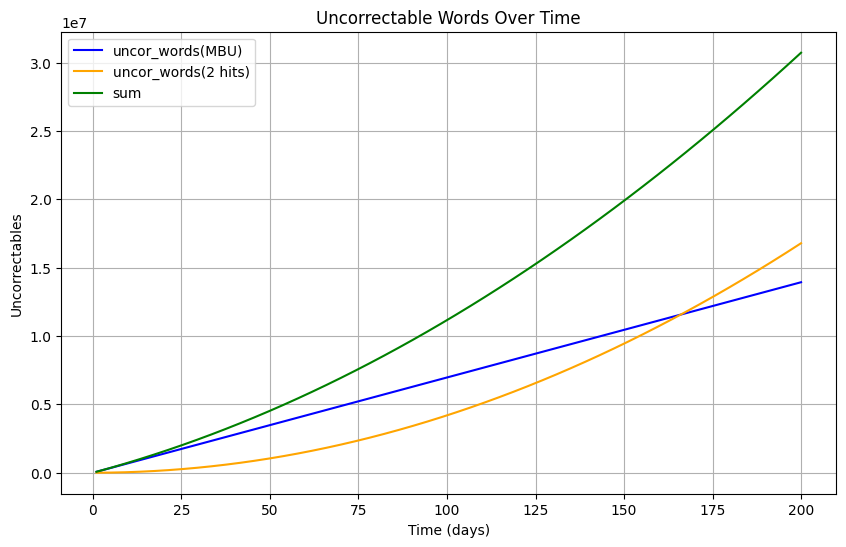

Text(0.5, 1.0, 'Total Uncorrectable Words Over Mission Lifetime')

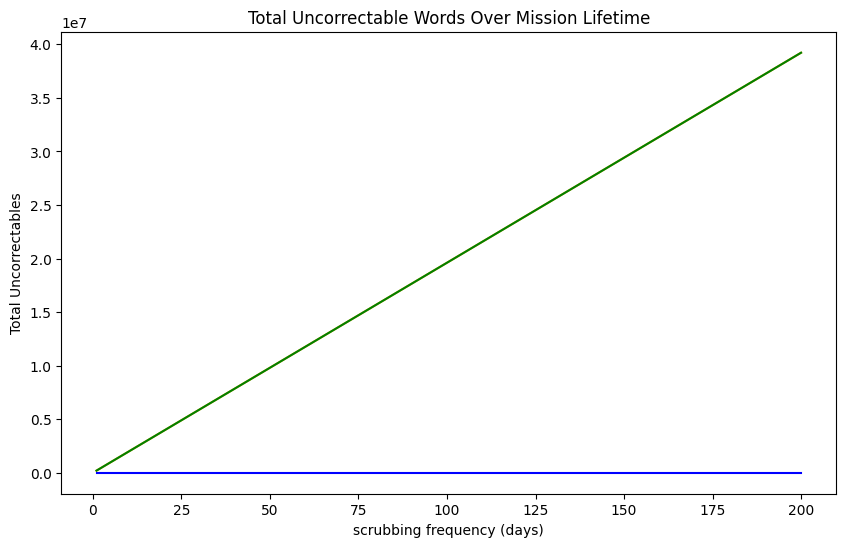

In [79]:
x = np.linspace(1, 200)  # scrub_frequency in days
plt.figure(figsize=(10, 6))
plt.plot(x, unc_MBU(x), label='uncor_words(MBU)', color='blue')
plt.plot(x, unc_2_hit(x), label='uncor_words(2 hits)', color='orange')
plt.plot(x, unc_MBU(x) + unc_2_hit(x), label='sum', color='green')
plt.xlabel('Time (days)')
plt.ylabel('Uncorrectables')
plt.title('Uncorrectable Words Over Time')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x, tot_unc_MBU(x), label='total uncor_words(MBU)', color='blue')
plt.plot(x, tot_unc_2_hit(x), label='total uncor_words(2    hits)', color='orange')
plt.plot(x, tot_unc_MBU(x) + tot_unc_2_hit(x), label='total sum', color='green')
plt.xlabel('scrubbing frequency (days)')    
plt.ylabel('Total Uncorrectables')
plt.title('Total Uncorrectable Words Over Mission Lifetime')   


In [105]:
#  Knowns
mission_lifetime = 5            # years
word_size = 512 + 69            # bytes
total_memory = 2 * 42 * 1e9     # bytes
spenvis_rate = 6e-12            # errors per bit per second
T = 1

#  Parameters
memory_fraction = 0.01
total_memory *= memory_fraction  # Use only a fraction of the total memory for the simulation

num_words = int(total_memory / word_size)

batch_size = 10_000
fail_words = []
generated_rate = []
vec = [5,10, 20,50, 100, 200, 300]  # Scrubbing frequencies in days
for scrubbing_frequency in vec:  # days
    t = scrubbing_frequency * 24 * 3600 
    lam = spenvis_rate * 8 * word_size * t # errors per word per scrubbing period
    
    # Calculate full scrubs and the leftover days
    total_days = mission_lifetime * 365
    n_scrub = int(total_days / scrubbing_frequency)
    remainder_days = total_days % scrubbing_frequency
    
    uncorrectables = 0
    errors = np.zeros(num_words)
    errors_nombu = np.zeros(num_words)

    # 1. Run the full scrubbing periods
    for n in range(n_scrub):
        for start in range(0, num_words, batch_size):
            end = min(start + batch_size, num_words)
            k = np.random.poisson(lam, end - start)
            errors_nombu[start:end] += k
            
            extra = np.random.choice([0,1,2], size=(end-start, k.max()), p=[0.80,0.15,0.05])
            mask = np.arange(k.max()) < k[:, None]
            k += (extra * mask).sum(axis=1)
            
            uncorrectables += np.sum(k > T)
            errors[start:end] += k

    # 2. Run one final partial period for the chopped-off remainder days
    if remainder_days > 0:
        t_rem = remainder_days * 24 * 3600
        lam_rem = spenvis_rate * 8 * word_size * t_rem
        
        for start in range(0, num_words, batch_size):
            end = min(start + batch_size, num_words)
            k = np.random.poisson(lam_rem, end - start)
            errors_nombu[start:end] += k
            
            extra = np.random.choice([0,1,2], size=(end-start, k.max()), p=[0.80,0.15,0.05])
            mask = np.arange(k.max()) < k[:, None]
            k += (extra * mask).sum(axis=1)
            
            uncorrectables += np.sum(k > T)
            errors[start:end] += k

    fail_words.append(int(uncorrectables / (memory_fraction)))
    generated_rate.append(np.sum(errors_nombu) / (total_memory * 8 * mission_lifetime * 365 * 24 * 3600))

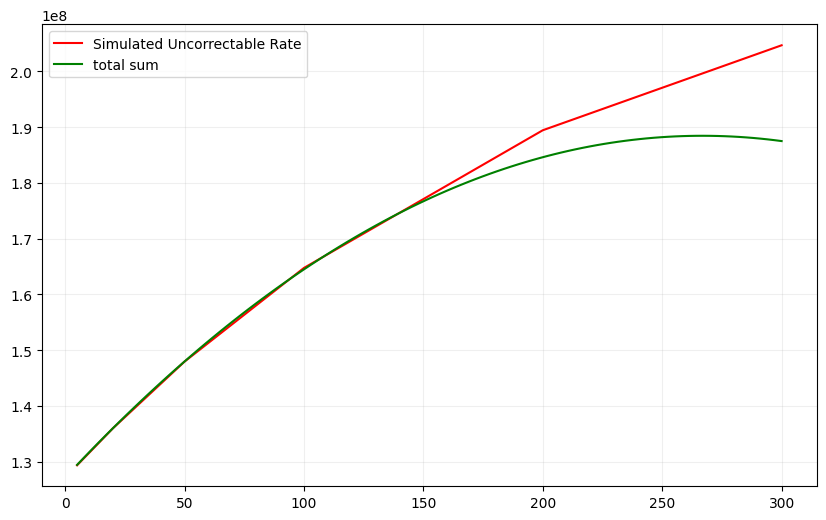

Text(0.5, 1.0, 'Total Uncorrectable Words Over Mission Lifetime')

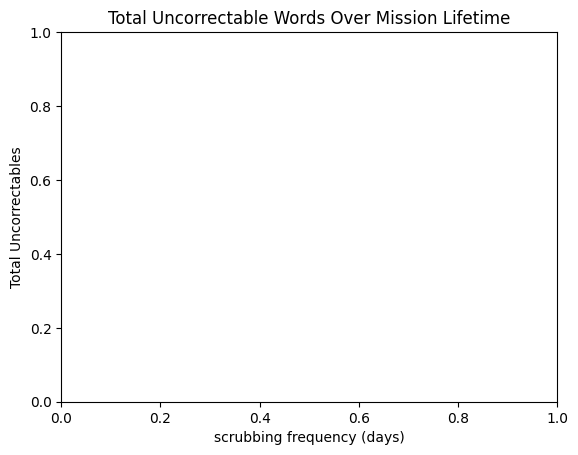

In [120]:
x = np.linspace(5, 300, 100)  # scrub_frequency in days
plt.figure(figsize=(10, 6))
plt.plot(vec, fail_words, label='Simulated Uncorrectable Rate', color='red')
plt.plot(x, tot_unc_MBU(x) + tot_unc_2_hit(x), label='total sum', color='green')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()


# plt.plot(x, tot_unc_MBU(x), label='total uncor_words(MBU)', color='blue')
# plt.plot(x, tot_unc_2_hit(x), label='total uncor_words(2    hits)', color='orange')

plt.xlabel('scrubbing frequency (days)')    
plt.ylabel('Total Uncorrectables')
plt.title('Total Uncorrectable Words Over Mission Lifetime')  

PLOT of the uncorrectables (T>1), sperimental vs theoretical

In [ ]:
x = np.linspace(0, 5e6, 1000)  # Time in seconds
plt.figure(figsize=(10, 6))
plt.plot(x / 86400, prob_MBU(x) + prob_2_hit(x), label='theoretical)', color='blue')
plt.plot(sc)
plt.xlabel('Time (days)')
plt.ylabel('Uncorrectables')
plt.legend()
plt.grid()
plt.show()